# Performing Exploratory Data Analysis
---

**Importing Required Libraries**

In [1]:
import pandas as pd
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sn
import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath(".."))
from src.config import Config

**Loading AGNews Dataset**

In [2]:
from datasets import load_dataset
dataset = load_dataset(Config.HF_DATASET)

In [3]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [4]:
# defining train and test datasets
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

In [5]:
# Difining Label name mappings
L2_LABEL_NAMES = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "SciTech"
}

L1_LABEL_NAMES = {
    0: "Hard News",
    1: "Soft News"
}

# Hierarchical Mappings
# World (0) -> Hard (0)
# Sports (1) -> Soft (1)
# Business (2) -> Hard (0)
# SciTech (3) -> Soft (1)

L2_TO_L1 = {
    0: 0,
    1: 1,
    2: 0,
    3: 1
}

In [6]:
train_df.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


**Adding hirarchy**

In [7]:
# Rename Label column and derive hierarchy labels
train_df = train_df.rename(columns = {"label": "l2_label"})
test_df = test_df.rename(columns = {"label" : "l2_label"})

# Adding L1 labels
train_df["l1_label"] = train_df["l2_label"].map(L2_TO_L1)
test_df["l1_label"] = train_df["l2_label"].map(L2_TO_L1)

In [8]:
train_df.head()

,text,l2_label,l1_label
0,Wall St. Bears Claw Back Into the Black (Reute...,2,0
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,0
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,0
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,0
4,"Oil prices soar to all-time record, posing new...",2,0


In [9]:
# Checking number of samples
print(f"Train: {len(train_df)} samples")
print(f"Test: {len(test_df)} samples")
print(f"Columns: {list(train_df.columns)}")

Train: 120000 samples
Test: 7600 samples
Columns: ['text', 'l2_label', 'l1_label']


**Checking Class Distribution**

In [10]:
# L2 Label Distribution (Train)
l2_counts = train_df["l2_label"].value_counts().sort_index()
for idx, cnt in l2_counts.items():
    print(f" [{idx}] {L2_LABEL_NAMES[idx]}: {cnt} samples")

 [0] World: 30000 samples
 [1] Sports: 30000 samples
 [2] Business: 30000 samples
 [3] SciTech: 30000 samples


In [11]:
# L1 Label Distribution (Train)
l1_counts = train_df["l1_label"].value_counts().sort_index()
for idx, cnt in l1_counts.items():
    print(f" [{idx}] {L1_LABEL_NAMES[idx]}: {cnt} samples")

 [0] Hard News: 60000 samples
 [1] Soft News: 60000 samples


In [12]:
# Extracting label names
l1_names = [L1_LABEL_NAMES[i] for i in sorted(L1_LABEL_NAMES)]
l2_names = [L2_LABEL_NAMES[i] for i in sorted(L2_LABEL_NAMES)]

In [13]:
l1_counts_df = l1_counts.reset_index()
l2_counts_df = l2_counts.reset_index()
l1_counts_df["l1_label"] = l1_counts_df["l1_label"].map(L1_LABEL_NAMES)
l2_counts_df["l2_label"] = l2_counts_df["l2_label"].map(L2_LABEL_NAMES)

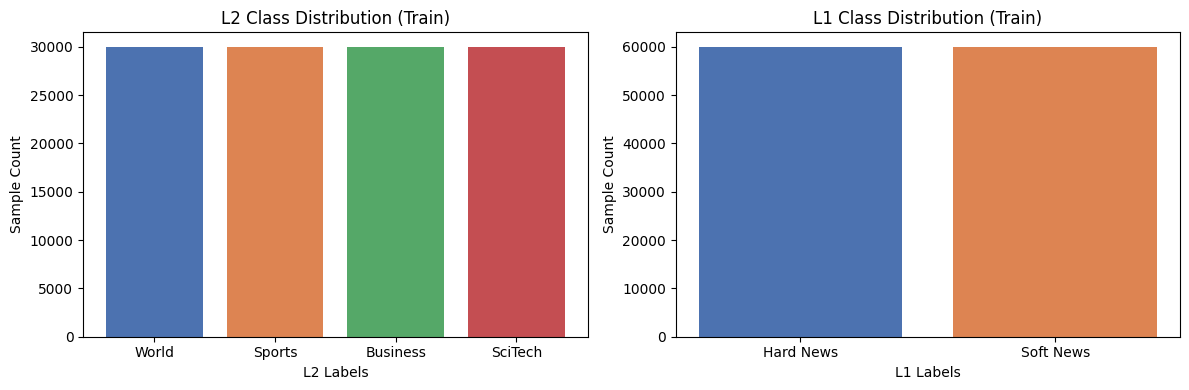

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(l2_names, l2_counts_df["count"], color = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
axes[0].set_title("L2 Class Distribution (Train)")
axes[0].set_ylabel("Sample Count")
axes[0].set_xlabel("L2 Labels")

axes[1].bar(l1_names, l1_counts_df["count"], color = ["#4C72B0", "#DD8452"])
axes[1].set_title("L1 Class Distribution (Train)")
axes[1].set_ylabel("Sample Count")
axes[1].set_xlabel("L1 Labels")

plt.tight_layout()
plt.show()
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)
fig.savefig(os.path.join(Config.OUTPUT_DIR, "class_distribution.png"), dpi=150)

**Text Length Distribution**

In [15]:
# Adding a column for word and character count respectively
train_df["word_count"] = train_df["text"].str.split().str.len()
train_df["char_count"] = train_df["text"].str.len()

In [16]:
train_df.head()

,text,l2_label,l1_label,word_count,char_count
0,Wall St. Bears Claw Back Into the Black (Reute...,2,0,21,144
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,0,36,266
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,0,36,232
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,0,36,256
4,"Oil prices soar to all-time record, posing new...",2,0,37,234


In [17]:
# Word count statistics (all classes)
train_df["word_count"].describe()

count    120000.000000
mean         37.847450
std          10.085245
min           8.000000
25%          32.000000
50%          37.000000
75%          43.000000
max         177.000000
Name: word_count, dtype: float64

In [18]:
# Word Count by L2 class
train_df.groupby("l2_label")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
l2_label,,,,,,,,
0,30000.0,38.884867,10.315517,11.0,33.0,39.0,44.0,145.0
1,30000.0,37.774733,8.870100,8.0,32.0,37.0,42.0,151.0
2,30000.0,37.538233,8.121983,8.0,32.0,37.0,42.0,134.0
3,30000.0,37.191967,12.417603,8.0,30.0,36.0,42.0,177.0


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label_id, label_name in L2_LABEL_NAMES.items():
    subset = train_df[train_df["l2_label"] == label_id]["word_count"]
    axes[0].hist(subset, bins=50, alpha=0.6, label=label_name, density=True)
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Density")
axes[0].set_title("Text Length Distribution by L2 Class")
axes[0].legend()
axes[0].axvline(x=128, color="red", linestyle="--", label="max_length=128")

# Cumulative coverage at max_length=128
coverage_128 = (train_df["word_count"] <= 128).mean()
coverage_64 = (train_df["word_count"] <= 64).mean()
axes[1].ecdf(train_df["word_count"])
axes[1].axvline(x=128, color="red", linestyle="--", label=f"128 tokens ({coverage_128:.1%} covered)")
axes[1].axvline(x=64, color="orange", linestyle="--", label=f"64 tokens ({coverage_64:.1%} covered)")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Cumulative Fraction")
axes[1].set_title("Cumulative Text Length Coverage", fontweight="bold")
axes[1].legend()

plt.tight_layout()
fig.savefig(os.path.join(Config.OUTPUT_DIR, "text_length_distribution.png"), dpi=150)
plt.close(fig)

**Sample Text Per Class**

In [32]:
for label_id in sorted(L2_LABEL_NAMES):
    subset = train_df[train_df["l2_label"] == label_id]
    sample = subset["text"].iloc[0]
    l1_name = L1_LABEL_NAMES[L2_TO_L1[label_id]]
    print(f"\n L1: {l1_name} | L2: {L2_LABEL_NAMES[label_id]}")
    print(f" Text: {sample[:200]}")


 L1: Hard News | L2: World
 Text: Venezuelans Vote Early in Referendum on Chavez Rule (Reuters) Reuters - Venezuelans turned out early\and in large numbers on Sunday to vote in a historic referendum\that will either remove left-wing P

 L1: Soft News | L2: Sports
 Text: Phelps, Thorpe Advance in 200 Freestyle (AP) AP - Michael Phelps took care of qualifying for the Olympic 200-meter freestyle semifinals Sunday, and then found out he had been added to the American tea

 L1: Hard News | L2: Business
 Text: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

 L1: Soft News | L2: SciTech
 Text: 'Madden,' 'ESPN' Football Score in Different Ways (Reuters) Reuters - Was absenteeism a little high\on Tuesday among the guys at the office? EA Sports would like\to think it was because "Madden NFL 20


**Check for missing labels**

In [36]:
train_df.isnull().sum()

text          0
l2_label      0
l1_label      0
word_count    0
char_count    0
dtype: int64